In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import time
import os
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

from sklearn.metrics import (mean_squared_error, 
                             mean_absolute_error, 
                             r2_score)

print("=== Data Loaded ===")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

=== Data Loaded ===
X_train : (161331, 12)
X_test  : (40333, 12)


In [2]:
from sklearn.linear_model import LinearRegression

print("Training Linear Regression...")
start = time.time()
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
end = time.time()

lr_pred = lr_model.predict(X_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print(f"Training complete in {(end-start):.1f} seconds!")
print(f"\n=== Linear Regression Results ===")
print(f"RMSE : {lr_rmse:.2f}")
print(f"MAE  : {lr_mae:.2f}")
print(f"R²   : {lr_r2:.4f}")

Training Linear Regression...
Training complete in 0.1 seconds!

=== Linear Regression Results ===
RMSE : 53.58
MAE  : 42.65
R²   : 0.9024


In [3]:
from sklearn.ensemble import RandomForestRegressor

print("Training Random Forest (limited complexity)...")
start = time.time()
rf_model = RandomForestRegressor(
    n_estimators=50,   # fewer trees
    max_depth=5,       # shallow trees — forces generalization
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
end = time.time()

rf_pred = rf_model.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print(f"Training complete in {(end-start):.1f} seconds!")
print(f"\n=== Random Forest Results ===")
print(f"RMSE : {rf_rmse:.2f}")
print(f"MAE  : {rf_mae:.2f}")
print(f"R²   : {rf_r2:.4f}")

Training Random Forest (limited complexity)...
Training complete in 2.2 seconds!

=== Random Forest Results ===
RMSE : 35.75
MAE  : 26.67
R²   : 0.9566


In [4]:
%pip install xgboost
from xgboost import XGBRegressor

print("Training XGBoost (limited complexity)...")
start = time.time()
xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=4,        # shallow trees
    learning_rate=0.1,  # slow learning rate
    subsample=0.8,      # use 80% of data per tree
    colsample_bytree=0.8, # use 80% of features per tree
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_train, y_train)
end = time.time()

xgb_pred = xgb_model.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print(f"Training complete in {(end-start):.1f} seconds!")
print(f"\n=== XGBoost Results ===")
print(f"RMSE : {xgb_rmse:.2f}")
print(f"MAE  : {xgb_mae:.2f}")
print(f"R²   : {xgb_r2:.4f}")

Note: you may need to restart the kernel to use updated packages.
Training XGBoost (limited complexity)...
Training complete in 0.9 seconds!

=== XGBoost Results ===
RMSE : 29.36
MAE  : 23.19
R²   : 0.9707


In [5]:
import os, pickle

os.makedirs('../models',  exist_ok=True)
os.makedirs('../reports', exist_ok=True)

with open('../models/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

size = os.path.getsize('../models/xgb_model.pkl')
print(f"=== Model Saved ===" )
print(f"  ../models/xgb_model.pkl  ({size/1024:.1f} KB)")

=== Model Saved ===
  ../models/xgb_model.pkl  (171.4 KB)


In [6]:
print("=" * 52)
print("        MODEL COMPARISON SUMMARY")
print("=" * 52)
print(f"{'Model':<22} {'RMSE':>7} {'MAE':>7} {'R²':>8}")
print("-" * 52)
print(f"{'Linear Regression':<22} {lr_rmse:>7.2f} {lr_mae:>7.2f} {lr_r2:>8.4f}")
print(f"{'Random Forest':<22} {rf_rmse:>7.2f} {rf_mae:>7.2f} {rf_r2:>8.4f}")
print(f"{'XGBoost':<22} {xgb_rmse:>7.2f} {xgb_mae:>7.2f} {xgb_r2:>8.4f}")
print("=" * 52)

best_rmse = min(lr_rmse, rf_rmse, xgb_rmse)
best_name = ['Linear Regression','Random Forest','XGBoost'][[lr_rmse,rf_rmse,xgb_rmse].index(best_rmse)]
print(f"  Best model : {best_name}")
print(f"  Best RMSE  : {best_rmse:.2f}")
print(f"  Best R²    : {max(lr_r2, rf_r2, xgb_r2):.4f}")
print("=" * 52)

        MODEL COMPARISON SUMMARY
Model                     RMSE     MAE       R²
----------------------------------------------------
Linear Regression        53.58   42.65   0.9024
Random Forest            35.75   26.67   0.9566
XGBoost                  29.36   23.19   0.9707
  Best model : XGBoost
  Best RMSE  : 29.36
  Best R²    : 0.9707


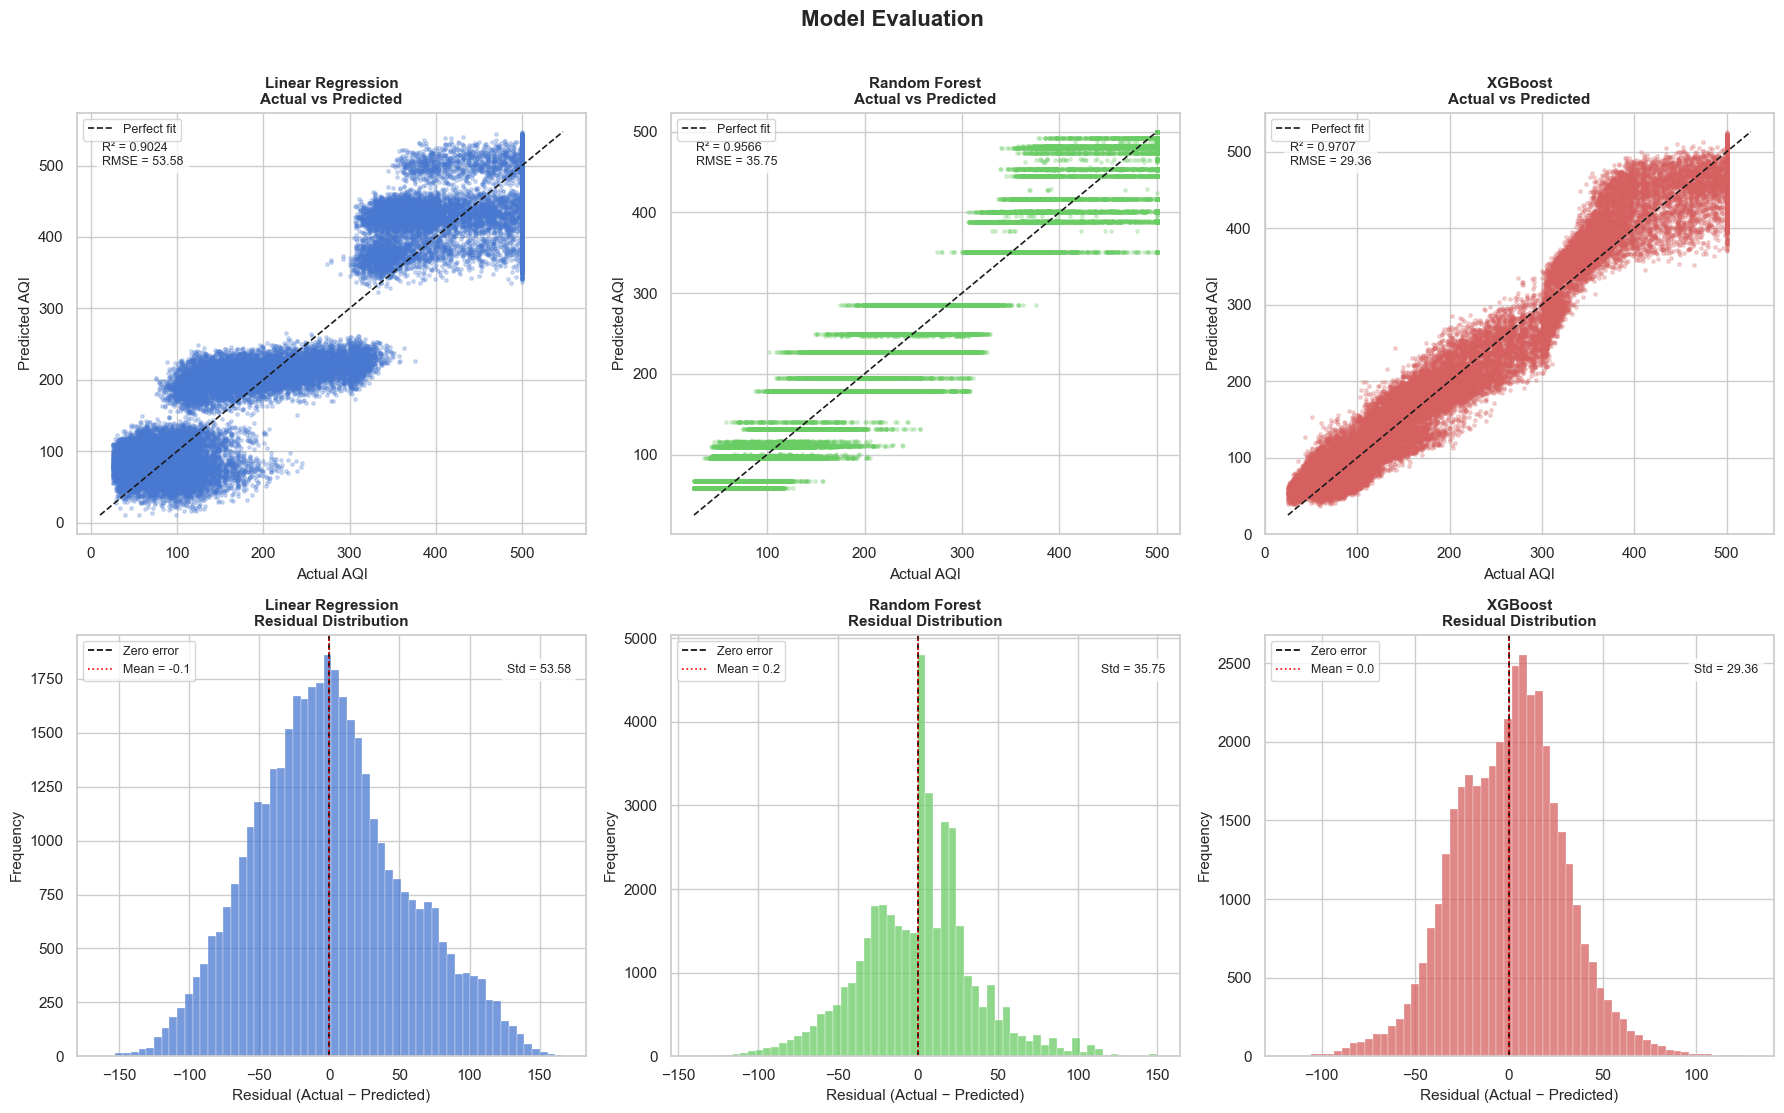

Plot saved to ../reports/evaluation_plots.png


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Model Evaluation', fontsize=16, fontweight='bold', y=1.01)

models = [
    ('Linear Regression', lr_pred),
    ('Random Forest',     rf_pred),
    ('XGBoost',           xgb_pred),
]
colors = ['#4878cf', '#6acc65', '#d65f5f']

# ── Row 1: Actual vs Predicted ──
for ax, (name, pred), color in zip(axes[0], models, colors):
    ax.scatter(y_test, pred, alpha=0.25, s=6, color=color, rasterized=True)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1.2, label='Perfect fit')
    ax.set_xlabel('Actual AQI',    fontsize=11)
    ax.set_ylabel('Predicted AQI', fontsize=11)
    ax.set_title(f'{name}\nActual vs Predicted', fontsize=11, fontweight='bold')
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    ax.text(0.05, 0.93, f'R² = {r2:.4f}\nRMSE = {rmse:.2f}',
            transform=ax.transAxes, fontsize=9,
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))
    ax.legend(fontsize=9)

# ── Row 2: Residual distribution ──
for ax, (name, pred), color in zip(axes[1], models, colors):
    residuals = y_test - pred
    ax.hist(residuals, bins=60, color=color, alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='black', linewidth=1.2, linestyle='--', label='Zero error')
    ax.axvline(residuals.mean(), color='red', linewidth=1.2,
               linestyle=':', label=f'Mean = {residuals.mean():.1f}')
    ax.set_xlabel('Residual (Actual − Predicted)', fontsize=11)
    ax.set_ylabel('Frequency',                     fontsize=11)
    ax.set_title(f'{name}\nResidual Distribution', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.text(0.97, 0.93, f'Std = {residuals.std():.2f}',
            transform=ax.transAxes, fontsize=9, ha='right',
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('../reports/evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to ../reports/evaluation_plots.png")

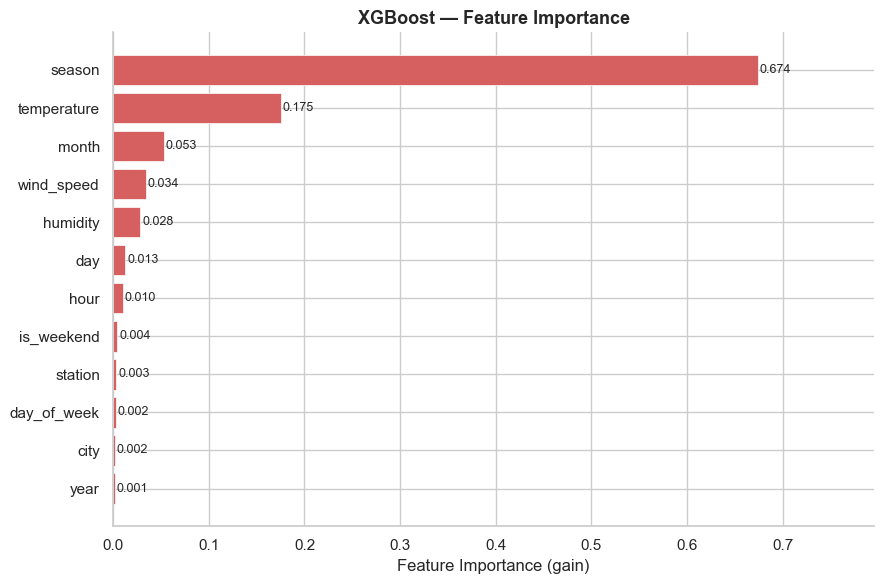


Top 3 features:
  season          : 0.6741
  temperature     : 0.1750
  month           : 0.0532


In [8]:
feature_names = X_train.columns.tolist()
importances = xgb_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(importance_df['Feature'], importance_df['Importance'],
               color='#d65f5f', edgecolor='white', linewidth=0.5)

# Value labels on bars
for bar, val in zip(bars, importance_df['Importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('Feature Importance (gain)', fontsize=12)
ax.set_title('XGBoost — Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlim(0, importance_df['Importance'].max() * 1.18)
sns.despine()
plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 3 features:")
for _, row in importance_df.iloc[::-1].head(3).iterrows():
    print(f"  {row['Feature']:<15} : {row['Importance']:.4f}")